In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df  = pd.read_csv('Student_Performance.csv')

In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

In [7]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

In [8]:
df.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


In [10]:
y = df['Performance Index']
X = df.drop('Performance Index', axis=1)

In [11]:
m,n = X.shape
print(m)

10000


In [13]:
train = int(0.8 *  m)

In [28]:
X_train, X_test, y_train, y_test = X[0:train], X[train:], y[0:train], y[train:] 

In [29]:
X_train = np.array(X_train)
y_train = np.array(y_train).reshape(train,1)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [16]:
w = np.zeros(5).reshape(5,1)

In [34]:
y = X_train.dot(w)

In [38]:

y_train - y

array([[91.],
       [65.],
       [45.],
       ...,
       [69.],
       [47.],
       [64.]], shape=(8000, 1))

In [30]:
print(w)
print(y_train)

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[91.]
 [65.]
 [45.]
 ...
 [69.]
 [47.]
 [64.]]


In [25]:
bias = 0

In [19]:
def loss_function(error):
    loss = np.mean(error**2)
    return loss

In [140]:
def gradient_descent(x,y,w,b,lr,epochs=100000):
    loss_history = []
    m = x.shape[0]
    for _ in range(epochs):
        y_pred = x.dot(w) + b
        error = y_pred - y
        dj_dw = (1/m) * x.T.dot(error)
        dj_db = np.mean(error)
        w -= lr*dj_dw
        b -= lr*dj_db
        loss_history.append(loss_function(error))
    return w,b,loss_history
        

In [141]:
w = w = np.zeros(5).reshape(5,1)
b = 0
w,b, loss_history = gradient_descent(X_train, y_train, w, bias,lr=0.000367)
print(loss_history[-1])

8.62151931729035


In [142]:
pred = X_test[0].dot(w) + b

In [143]:
print(pred)

[30.22295806]


In [144]:
print(y_test[0])

28.0


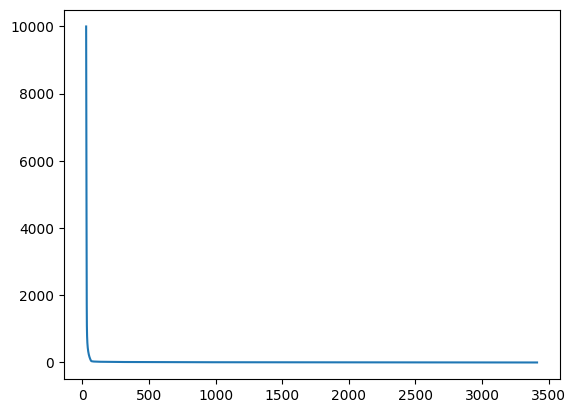

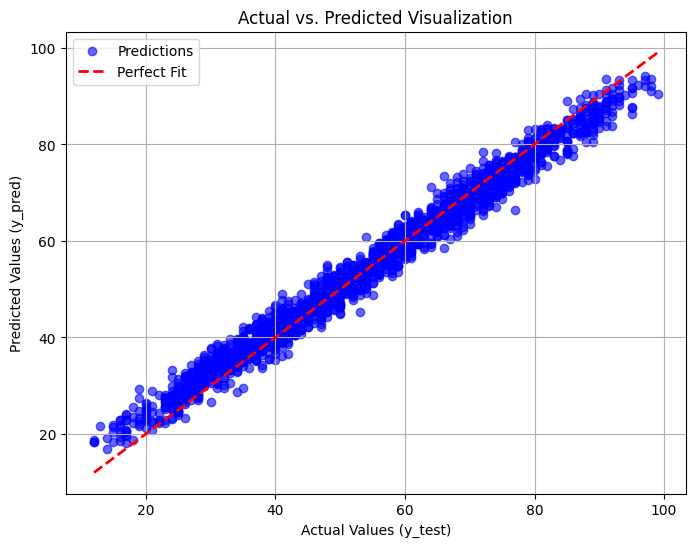

In [145]:

y_pred_test = X_test.dot(w) + b

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6, label='Predictions')

ideal_line = [min(y_test), max(y_test)]
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Visualization')
plt.legend()
plt.grid(True)
plt.show()

In [153]:
pd.DataFrame({
    'Actual': y_test.flatten() if hasattr(y_test, 'flatten') else y_test, 
    'Prediction': y_pred_test.flatten()
})

,Actual,Prediction
0,28.0,30.222958
1,35.0,34.850605
2,63.0,59.592563
3,71.0,71.221317
4,78.0,76.755801
...,...,...
1995,23.0,26.578316
1996,58.0,55.144713
1997,74.0,70.423380
1998,95.0,91.628121


In [156]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.326852908538766
MSE : 8.717288446173905
RMSE: 2.952505452352951
R²  : 0.976129397707829
